In [1]:
## Import libries
import numpy as np
import pandas as pd
import os
import re
import glob
import json
import csv
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pyranges as pr
import pysam
from matplotlib.patches import Patch

# from scipy.stats import mannwhitneyu, stats
# from statannotations.Annotator import Annotator

current_directory = os.getcwd()
print("Current Directory:", current_directory)
pd.set_option("display.max_columns", None)


Current Directory: /mnt/NAS3/home/jiwon/ECTRES/python


In [2]:
summary=pd.read_csv('/mnt/NAS3/home/jiwon/ECTRES/summary/aaSuite_germline_ms/10X/SV_summaries/merged_SV_summary_all.tsv',sep='\t')
print(summary.shape)
summary.head(2)

(1618, 14)


,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,45643848,20,45646230,foldback,4,Linear,++,45643847,45646229,NaN,NaN
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,46843243,20,47214580,inversion,2,Linear,--,46843244,47214581,NaN,NaN


In [8]:
aaSuite_gemline_ms=pd.read_csv('../summary/aaSuite_germline_ms/10X/aaSuite_gemline_ms_all_20260430.csv')
aaSuite_gemline_ms.shape
aaSuite_gemline_ms.head(2)
sample_map = aaSuite_gemline_ms[['aa_barcode','source_barcode','sample_id']].drop_duplicates()
# sample_map.to_csv('../summary/sample_map.csv',index=False)
sample_map[sample_map['sample_id']=='EG_X01'].head()
# aaSuite_gemline_ms['source_barcode'].value_counts()

,aa_barcode,source_barcode,sample_id
144,ECTRES-H2170-0001-TPX-A10-WGS-8CY686,ECGI1,EG_X01


In [9]:
summary=pd.merge(summary,sample_map, on='aa_barcode', how='left')
summary.shape

(1618, 16)

In [12]:
print(summary['source_barcode'].value_counts())
summary.head(2)

source_barcode
EFM19    690
H2170    533
ECGI1    395
Name: count, dtype: int64


,aa_barcode,amplicon_number,chrom1,pos1,chrom2,pos2,sv_type,read_support,features,orientation,pos1_flanking_coordinate,pos2_flanking_coordinate,homology_length,homology_sequence,source_barcode,sample_id
0,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,45643848,20,45646230,foldback,4,Linear,++,45643847,45646229,NaN,NaN,EFM19,EFM_5
1,ECTRES-EFM19-0001-TPX-A05-WGS-4GXSY5,amplicon14,20,46843243,20,47214580,inversion,2,Linear,--,46843244,47214581,NaN,NaN,EFM19,EFM_5


In [73]:
SOURCE     = "ECGI1"   # source_barcode
# ERBB2 region (GRCh37)
CHROM  = "17"
START  = 37844167
END    = 37884915
WINDOW = 500   # breakpoint matching tolerance (bp)


In [74]:
# source 필터
df = summary[summary["source_barcode"] == SOURCE].copy()
print(f"샘플 수: {df['sample_id'].nunique()} | SV rows: {len(df)}")
df["sample_id"].value_counts()

샘플 수: 34 | SV rows: 395


sample_id
parental    76
EG_25       15
EG_14       14
EG_17       14
EG_23       14
EG_31       14
EG_4        13
EG_2        12
EG_16       12
EG_6        12
EG_5        11
EG_33       11
EG_22       11
EG_26       11
EG_11       10
EG_28       10
EG_1        10
EG_18       10
EG_9        10
EG_15        9
EG_3         9
EG_8         9
EG_13        9
EG_19        9
EG_X01       8
EG_20        7
EG_30        7
EG_7         7
EG_29        7
EG_12        7
EG_32        6
EG_24        6
EG_27        3
EG_10        2
Name: count, dtype: int64

In [75]:
# # ERBB2 region 필터
# def in_erbb2(row):
#     c1 = str(row["chrom1"]) == CHROM and START - WINDOW <= row["pos1"] <= END + WINDOW
#     c2 = str(row["chrom2"]) == CHROM and START - WINDOW <= row["pos2"] <= END + WINDOW
#     return c1 or c2

# df_erbb2 = df[df.apply(in_erbb2, axis=1)].copy()
# print(f"ERBB2 region SV: {len(df_erbb2)} rows")
# df_erbb2.head()

In [76]:
parental = df[df["sample_id"] == "parental"].copy().reset_index(drop=True)
print(f"Parental SV: {len(parental)}")

parental["bp_id"] = (
    parental["chrom1"].astype(str) + ":" + parental["pos1"].astype(str)
    + "--"
    + parental["chrom2"].astype(str) + ":" + parental["pos2"].astype(str)
    + "_" + parental["sv_type"]
)

parental[["bp_id", "sv_type", "features", "read_support"]]

Parental SV: 76


,bp_id,sv_type,features,read_support
0,5:56986037--5:56987192_foldback,foldback,NaN,5
1,5:58988144--7:80802053_interchromosomal,interchromosomal,NaN,7
2,5:58988353--7:80801604_interchromosomal,interchromosomal,NaN,2
3,6:56230073--6:56231562_foldback,foldback,NaN,2
4,6:57572881--6:57585100_foldback,foldback,unknown,2
...,...,...,...,...
71,4:4552167--5:2069790_interchromosomal,interchromosomal,NaN,4
72,4:4552342--5:2069820_interchromosomal,interchromosomal,NaN,3
73,5:1044708--5:1045398_duplication-like,duplication-like,NaN,3
74,5:1903552--5:3332618_inversion,inversion,NaN,2


In [77]:
clones      = sorted([s for s in df["sample_id"].unique() if s != "parental"])
all_samples = ["parental"] + clones
clone_df    = df[df["sample_id"] != "parental"].copy()

print(f"Clone 수: {len(clones)}")

matrix = pd.DataFrame(index=parental["bp_id"], columns=all_samples, data=0)
matrix.index.name = "breakpoint_id"

# parental read support 채우기
for _, row in parental.iterrows():
    matrix.loc[row["bp_id"], "parental"] = row["read_support"]

# clone 매칭 (±WINDOW bp)
for _, p_row in parental.iterrows():
    for clone_id in clones:
        c_df = clone_df[clone_df["sample_id"] == clone_id]
        if c_df.empty:
            continue
        matched = c_df[
            (
                (c_df["chrom1"].astype(str) == str(p_row["chrom1"])) &
                (c_df["pos1"].between(p_row["pos1"] - WINDOW, p_row["pos1"] + WINDOW))
            ) | (
                (c_df["chrom2"].astype(str) == str(p_row["chrom2"])) &
                (c_df["pos2"].between(p_row["pos2"] - WINDOW, p_row["pos2"] + WINDOW))
            )
        ]
        if not matched.empty:
            matrix.loc[p_row["bp_id"], clone_id] = matched["read_support"].max()

# meta 컬럼 붙이기
meta   = parental[["bp_id", "sv_type", "features", "chrom1", "pos1", "chrom2", "pos2"]].set_index("bp_id")
matrix = meta.join(matrix)

matrix

Clone 수: 33


,sv_type,features,chrom1,pos1,chrom2,pos2,parental,EG_1,EG_10,EG_11,EG_12,EG_13,EG_14,EG_15,EG_16,EG_17,EG_18,EG_19,EG_2,EG_20,EG_22,EG_23,EG_24,EG_25,EG_26,EG_27,EG_28,EG_29,EG_3,EG_30,EG_31,EG_32,EG_33,EG_4,EG_5,EG_6,EG_7,EG_8,EG_9,EG_X01
bp_id,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,,
5:56986037--5:56987192_foldback,foldback,NaN,5,56986037,5,56987192,5,0,0,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,5,0,0,0,0,0,3,0,0,0,0,0,0,0,0,0
5:58988144--7:80802053_interchromosomal,interchromosomal,NaN,5,58988144,7,80802053,7,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5:58988353--7:80801604_interchromosomal,interchromosomal,NaN,5,58988353,7,80801604,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6:56230073--6:56231562_foldback,foldback,NaN,6,56230073,6,56231562,2,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
6:57572881--6:57585100_foldback,foldback,unknown,6,57572881,6,57585100,2,0,0,2,0,0,0,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,2,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4:4552167--5:2069790_interchromosomal,interchromosomal,NaN,4,4552167,5,2069790,4,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4:4552342--5:2069820_interchromosomal,interchromosomal,NaN,4,4552342,5,2069820,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
5:1044708--5:1045398_duplication-like,duplication-like,NaN,5,1044708,5,1045398,3,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [78]:
matrix['features'].unique()

array([nan, 'unknown', 'BFB', 'Complex-non-cyclic', 'Linear', 'ecDNA',
       'ecDNA|unknown'], dtype=object)

In [79]:
matrix_vals     = matrix[all_samples]
n_shared        = (matrix_vals[clones] > 0).any(axis=1).sum()
n_parental_only = (matrix_vals[clones] == 0).all(axis=1).sum()

print(f"Parental breakpoints 전체 : {len(matrix)}")
print(f"Clone에서도 발견됨        : {n_shared}")
print(f"Parental only             : {n_parental_only}")

# clone별 발견된 parental SV 수
clone_hit = (matrix_vals[clones] > 0).sum(axis=0)
print(f"\nClone별 parental SV 발견 수:")
print(clone_hit.to_string())

Parental breakpoints 전체 : 76
Clone에서도 발견됨        : 47
Parental only             : 29

Clone별 parental SV 발견 수:
EG_1      11
EG_10      2
EG_11     10
EG_12      7
EG_13     10
EG_14     11
EG_15      9
EG_16     11
EG_17     14
EG_18      9
EG_19      9
EG_2      10
EG_20      7
EG_22     11
EG_23     12
EG_24      6
EG_25     13
EG_26     10
EG_27      3
EG_28      8
EG_29      6
EG_3       6
EG_30      6
EG_31     15
EG_32      7
EG_33     12
EG_4      13
EG_5      12
EG_6      10
EG_7       6
EG_8       9
EG_9       9
EG_X01     8


<ipython-input-80-60512af8fbb4>:70: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


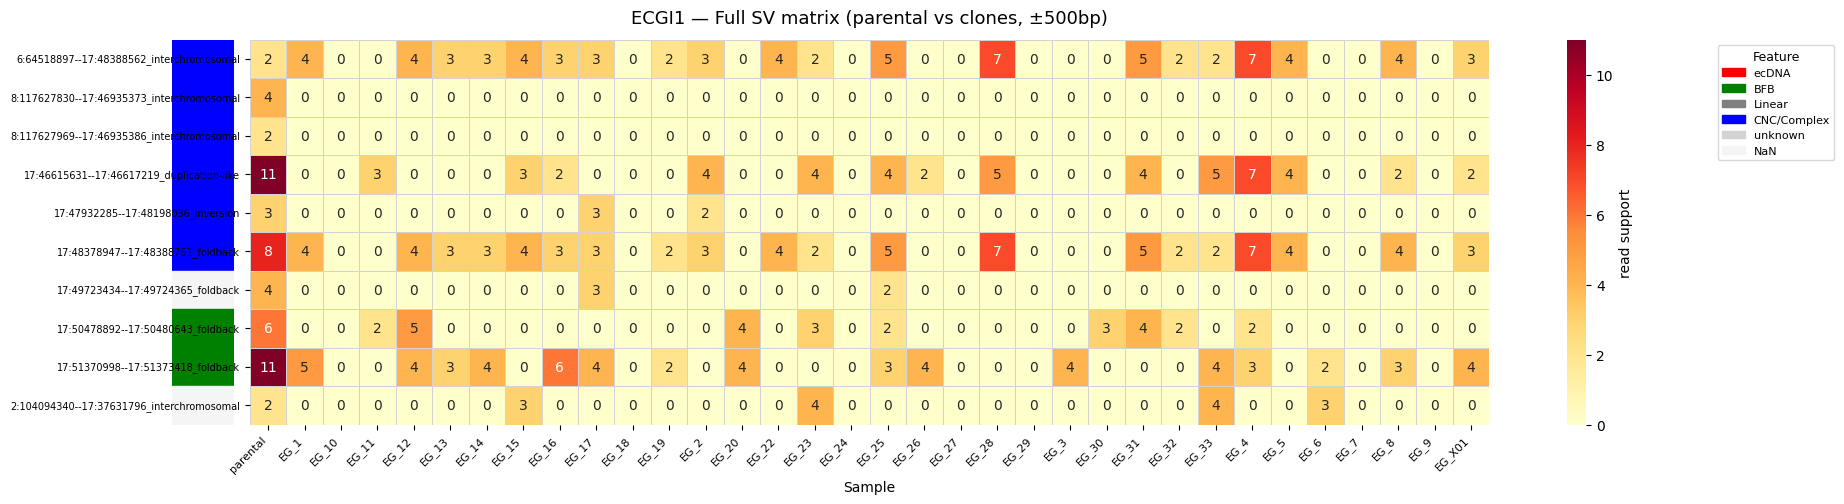

In [80]:
# heat_data = matrix[all_samples].astype(float)
# chr17 관련 SV만 필터
heat_data = matrix[
    (matrix["chrom1"].astype(str) == "17") |
    (matrix["chrom2"].astype(str) == "17")
][all_samples].astype(float)


# 한 번도 clone에서 발견 안 된 row는 시각화에서 제외 (선택)
# heat_data = heat_data[(heat_data[clones] > 0).any(axis=1)]

# ── Feature color bar 준비 ──────────────────────────────────────────
feature_cmap = {
    "ecDNA"            : "red",
    "ecDNA|unknown"    : "red",
    "BFB"              : "green",
    "Linear"           : "gray",
    "CNC"              : "blue",
    "Complex-non-cyclic": "blue",
    "unknown"          : "lightgray",
}
DEFAULT_COLOR = "whitesmoke"

features_aligned = matrix.loc[heat_data.index, "features"]
row_colors = features_aligned.map(lambda f: feature_cmap.get(str(f), DEFAULT_COLOR))

# ── Figure layout: color bar(1) + heatmap(N) ───────────────────────
n_rows = len(heat_data)
n_cols = len(all_samples)
fig_w  = max(14, n_cols * 0.6)
fig_h  = max(5,  n_rows * 0.5)

fig, (ax_cb, ax_hm) = plt.subplots(
    1, 2,
    figsize=(fig_w + 0.6, fig_h),
    gridspec_kw={"width_ratios": [0.04, 1], "wspace": 0.02}
)

# feature color bar (왼쪽)
for i, color in enumerate(row_colors):
    ax_cb.add_patch(plt.Rectangle((0, n_rows - i - 1), 1, 1, color=color))
ax_cb.set_xlim(0, 1)
ax_cb.set_ylim(0, n_rows)
ax_cb.axis("off")

# heatmap (오른쪽)
sns.heatmap(
    heat_data,
    cmap="YlOrRd",
    linewidths=0.4,
    linecolor="lightgray",
    annot=True,
    fmt=".0f",
    cbar_kws={"label": "read support"},
    ax=ax_hm
)
ax_hm.set_title(f"{SOURCE} — Full SV matrix (parental vs clones, ±{WINDOW}bp)", fontsize=13, pad=12)
ax_hm.set_xlabel("Sample")
ax_hm.set_ylabel("")
ax_hm.set_xticklabels(ax_hm.get_xticklabels(), rotation=45, ha="right", fontsize=8)
ax_hm.set_yticklabels(ax_hm.get_yticklabels(), fontsize=7)

# feature legend
legend_items = [
    plt.Rectangle((0,0), 1, 1, color=c, label=k)
    for k, c in {"ecDNA": "red", "BFB": "green", "Linear": "gray", "CNC/Complex": "blue", "unknown": "lightgray", "NaN": "whitesmoke"}.items()
]
ax_hm.legend(handles=legend_items, title="Feature", bbox_to_anchor=(1.18, 1), loc="upper left", fontsize=8, title_fontsize=9)

plt.tight_layout()
# out_fig = os.path.join(OUTPUT_DIR, f"{SOURCE}_SV_heatmap.pdf")
# plt.savefig(out_fig, dpi=150, bbox_inches="tight")
plt.show()
# print(f"저장: {out_fig}")